In [ ]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml
import copy
import time

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

from torch.nn.utils import parameters_to_vector 
#import torch.nn.utils.prune as prune

import sys
sys.path.append('../../')
sys.path.append('../')

from src import prune 
from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu
from src import initializations

from train_mod_cog import RNNModel

device = eg_utils.get_device()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


['/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf


In [2]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments

In [3]:
results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined")
os.listdir(results_dir)

['eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss']

In [4]:
# comparing 1e-7 eg, 1e-6 gd
exp_names = []
for exp_name in os.listdir(results_dir):
    if exp_name.startswith("eg"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("gd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
print(exp_names)

# reformat exp_name for use as a key
exp_folders = au.DotDict({au.format_exp_as_key(f):results_dir/f for f in exp_names})
results_dict = au.load_results(exp_folders)

['eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss', 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss']


In [5]:
# Add colours to exps
# https://www.datylon.com/blog/data-visualization-for-colorblind-readers
results_dict.eg_normal.c = "#fec615" # golden yellow
results_dict.eg_uniform.c = "green" #ff9408" # tangerine
results_dict.eg_log_normal.c = "#f05039" # orangey red

results_dict.gd_log_normal.c = "#1f449c" # blue
results_dict.gd_normal.c = "#8af1fe"
results_dict.gd_uniform.c = "#9e43a2"

In [6]:
def get_model(cfg):
    input_size = 115 
    output_size = 17
    model = RNNModel(input_size, cfg.model.hidden_size, output_size)
    if cfg.update_alg == "eg":
        eg_utils.set_split_bias(model)
        print("Setting split bias")
    return model

def load_ckpt(model, ckpt_path):
    device = eg_utils.get_device()
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model

In [7]:
def get_non_bias_params(model):
    """returns a list of parameters that are not biases"""
    non_bias_params = []
    for n, p in model.named_parameters():
        if "bias" in n: continue
        else : non_bias_params.append(p)
    return non_bias_params

def calc_cosine_similarity(vec1, vec2):
    with torch.no_grad():
        return vec1@vec2 / (vec1.norm() * vec2.norm())
    
def get_non_bias_pruneparams(model, verbose=False):
    """
    Note torch.nn.utils.prune expects iterables of (module, parameter_name) pairs 
    """
    parameters = []
    for mod_name, mod in model.named_modules():
        for n, p in mod.named_parameters(recurse=False):
            if "bias" in n: continue
            else : 
                parameters.append((mod, n))
                if verbose: print(f"appended {mod_name}:{n}, {p.shape} to params")

    return parameters

def prune_and_clean_prune_param(module_pnames_iterable, amount, inverse_magnitude):
    prune.global_unstructured(module_pnames_iterable, pruning_method=prune.L1Unstructured,
                              amount=amount, inverse_magnitude=inverse_magnitude)
    for mod, pname in module_pnames_iterable:
        prune.remove(mod, pname)

In [8]:
def get_cos_similarities(model, base_model, prune_props, ckpt, inverse_magnitude=False):
    cos_sims = []
    base_model = load_ckpt(base_model, ckpt)
    base_params = parameters_to_vector(get_non_bias_params(base_model)).detach()
    for prop in prune_props:
        model = load_ckpt(model, ckpt)  # fresh weights each prop: amounts are absolute fractions
        to_prune = get_non_bias_pruneparams(model)
        prune_and_clean_prune_param(to_prune, prop, inverse_magnitude=inverse_magnitude)
        model_params = parameters_to_vector(get_non_bias_params(model)).detach()
        cos_sims.append(calc_cosine_similarity(base_params, model_params).cpu())
    return cos_sims

In [9]:
# Grab checkpoints
gd_log_normal_init = results_dict.gd_log_normal.seed_7.epoch_ckpts[0]
gd_uniform_init = results_dict.gd_uniform.seed_7.epoch_ckpts[0]
gd_normal_init = results_dict.gd_normal.seed_7.epoch_ckpts[0]

idx = -2
gd_log_normal_final_ckpt = results_dict.gd_log_normal.seed_7.epoch_ckpts[idx]
gd_uniform_final_ckpt = results_dict.gd_uniform.seed_7.epoch_ckpts[idx]
gd_normal_final_ckpt = results_dict.gd_normal.seed_7.epoch_ckpts[idx]

eg_log_normal_final_ckpt = results_dict.eg_log_normal.seed_7.epoch_ckpts[idx]
eg_uniform_final_ckpt = results_dict.eg_uniform.seed_7.epoch_ckpts[idx]
eg_normal_final_ckpt = results_dict.eg_normal.seed_7.epoch_ckpts[idx]

# Create models
gd_exp = results_dict.gd_log_normal.seed_7
eg_exp = results_dict.eg_log_normal.seed_7
gd_model = get_model(gd_exp.cfg)
eg_model = get_model(eg_exp.cfg)

gd_model_base = get_model(gd_exp.cfg)
eg_model_base = get_model(eg_exp.cfg)

Setting split bias
Setting split bias


In [10]:
#prune_props_coarse = list(np.logspace(np.log10(1e-4), np.log10(0.95), 30))
prune_props_coarse = list(np.logspace(np.log10(1e-6), np.log10(0.95), 30))
print(prune_props_coarse)

[np.float64(1e-06), np.float64(1.6074164192025474e-06), np.float64(2.583787544721939e-06), np.float64(4.153222523117081e-06), np.float64(6.675958076260227e-06), np.float64(1.0731044625688542e-05), np.float64(1.7249257326527013e-05), np.float64(2.7726739445709357e-05), np.float64(4.456841623598416e-05), np.float64(7.164000403557432e-05), np.float64(0.00011515531875851904), np.float64(0.0001851025501309466), np.float64(0.00029753687831674653), np.float64(0.0004782656635246087), np.float64(0.0007687720802902569), np.float64(0.001235736864483058), np.float64(0.0019863437257839405), np.float64(0.003192881519005068), np.float64(0.005132290178217117), np.float64(0.00824972750057816), np.float64(0.013260747438376127), np.float64(0.021315543163343907), np.float64(0.0342629540649796), np.float64(0.055074834934430876), np.float64(0.08852819395847442), np.float64(0.14230167253119952), np.float64(0.22873804490663424), np.float64(0.36767728907921343), np.float64(0.5910105114338091), np.float64(0.95)

In [11]:
torch.cuda.is_available()

True

In [12]:
eg_cos_sims_ln = {}
idx = -2
for seed_key in results_dict.eg_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key, end=",")
    ckpt = results_dict.eg_log_normal[seed_key].epoch_ckpts[idx]
    eg_cos_sims_ln[seed_key] = get_cos_similarities(eg_model, eg_model_base, prune_props_coarse,
                                                    ckpt, inverse_magnitude=True)


seed_5,

seed_6,

seed_7,

seed_8,

seed_9,

In [13]:
gd_cos_sims_ln = {}
idx = -2
for seed_key in results_dict.gd_log_normal.keys():
    if not seed_key.startswith("seed"): continue
    print(seed_key, end=",")
    ckpt = results_dict.gd_log_normal[seed_key].epoch_ckpts[idx]
    gd_cos_sims_ln[seed_key] = get_cos_similarities(gd_model, gd_model_base, prune_props_coarse,
                                                    ckpt, inverse_magnitude=True)


seed_5,

seed_6,

seed_7,

seed_8,

seed_9,

In [14]:
# stack into array
gd_arr = np.array(list(gd_cos_sims_ln.values())).T
eg_arr = np.array(list(eg_cos_sims_ln.values())).T



In [15]:
cache_dir = Path("/network/projects/linclab_users/eg/modcog/analysis/reverse_pruning")
np.savez(cache_dir/"cos_sim_reverse_pruning_s7fix.npz", eg=eg_arr, gd=gd_arr)

In [16]:
plot_data = np.load(cache_dir/"cos_sim_reverse_pruning_s7fix.npz")
eg_arr = plot_data["eg"]
gd_arr = plot_data["gd"]

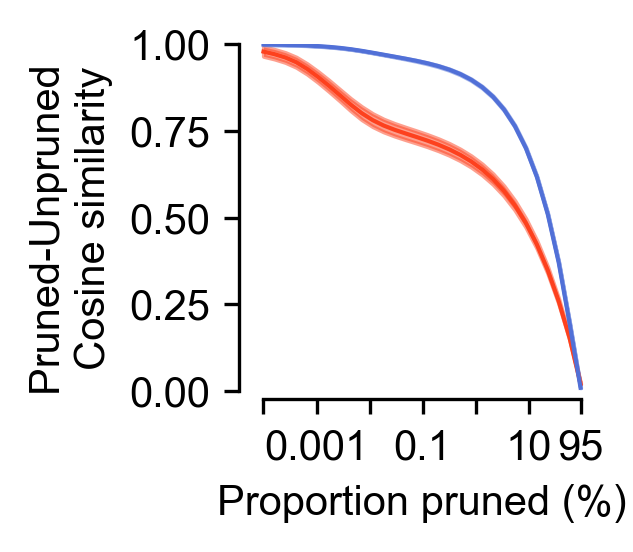

In [17]:
plt.figure(figsize=(1.5,1.5), dpi=300)
gd_c, eg_c = "#5170d7", "#fd411e"
x_pct = 100 * np.array(prune_props_coarse)  # axis units = %

plt.fill_between(x_pct, eg_arr.mean(1)-eg_arr.std(1), eg_arr.mean(1)+eg_arr.std(1), color=eg_c, alpha=0.5)
plt.plot(x_pct, eg_arr.mean(1), color=eg_c, lw=1)
plt.fill_between(x_pct, gd_arr.mean(1)-gd_arr.std(1), gd_arr.mean(1)+gd_arr.std(1), color=gd_c, alpha=0.5)
plt.plot(x_pct, gd_arr.mean(1), color=gd_c, lw=1)

plt.xscale("log"); plt.ylim(0., 1)
plt.ylabel("Pruned-Unpruned  \nCosine similarity"); plt.xlabel("Proportion pruned (%)")
decades = list(10.0 ** np.arange(-4, 2)) + [95]
plt.xticks(decades, ["", "0.001", "", "0.1", "", "10", "95"])
sns.despine(offset=2, trim=True)
plt.savefig("../figs/reverse_pruning/cos_sim_ln_inverse_s7fix.pdf", transparent=True, bbox_inches="tight")

# Next: get 0 shot drop in performance when pruning

- this next section should be run on a gpu

In [18]:
@dataclass
class DataConfig:
    batch_size: int = 512
    seq_len:int = 350
    copy_data_to_device_mem: bool = False
    num_workers: int = 0
    pin_memory: bool = True

cfg = DataConfig()

# load data
# data_dir = Path("/network/scratch/c/cornforj/eg_paper/mod_cog_data_v2")
data_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/data_v2")
print(os.listdir(data_dir)[:])

loaders = {}
for split in ["train", "val", "test"]:
    dataset = mcdu.ModCogDataset(data_dir, split=split, in_memory=cfg.copy_data_to_device_mem)
    loaders[split] = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=split=="train",
                                num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)

['mod_cog_test.npz', 'mod_cog_test_x.memmap', 'mod_cog_test_y.memmap', 'mod_cog_train.npz', 'mod_cog_train_x.memmap', 'mod_cog_train_y.memmap', 'mod_cog_val.npz', 'mod_cog_val_x.memmap', 'mod_cog_val_y.memmap', 'slurm-4893722.out']
Loading train memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading val memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2
Loading test memmap files /network/projects/_groups/linclab_users/eg/modcog/data_v2


In [19]:
from train_mod_cog import ModCogLossMSE, ModCogLossCombined, compute_acc_with_fixation_unit

@torch.no_grad()
def evaluate_model(model, loaders, custom_loss=True, mse_only_custom_loss=False,
                  epoch_idx=None, debug=False, verbose=False):
    """This is only used when using cached data."""
    if epoch_idx is None: epoch_idx = 0
    results_dict = {}
    device = eg_utils.get_device()
    model.eval()

    if mse_only_custom_loss:
        full_loss = ModCogLossMSE()
    else:
        full_loss = ModCogLossCombined(label_smoothing=0.1)

    ce_criterion = torch.nn.CrossEntropyLoss()

    for split in ["test"]:
        loader = loaders[split]
        accs = []
        dec_accs = []
        losses = []
        for i, (inputs, labels) in enumerate(loader):
            inputs = inputs.to(device)
            task_rules = inputs[:,:,-1]
            one_hot_rule_inputs = torch.nn.functional.one_hot(task_rules.long(), num_classes=82).float()
            inputs = torch.cat([inputs[:,:,:-1], one_hot_rule_inputs], dim=-1)
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            dec_mask = inputs[:, :, 0] == 0

            acc, dec_acc = compute_acc_with_fixation_unit(outputs, labels, dec_mask)

            if custom_loss:
                loss = full_loss(outputs, labels, dec_mask)[0]  # [0] ignores individial .item()-ized losses
            else:
                loss = ce_criterion(input=outputs.permute(0,2,1), target=labels)
            accs.append(acc)
            dec_accs.append(dec_acc)
            losses.append(loss.item())
            #print(i)
            if debug and i > 20: break
        mean_acc = np.mean(accs)
        mean_dec_acc = np.mean(dec_accs)
        mean_loss = np.mean(losses)
        if verbose:
            print(f"{epoch_idx}:{split} Acc: {mean_acc:.2f}, Dec Acc: {mean_dec_acc:.2f}, Loss: {mean_loss:.2f}")
        results_dict[f"{split}_Acc"] = mean_acc
        results_dict[f"{split}_Dec_Acc"] = mean_dec_acc
        results_dict[f"{split}_Loss"] = mean_loss

    return results_dict



In [20]:
def baseline_dec_acc(model, runs, idx=-2):
    """Unpruned Dec Acc per seed (for reference lines)."""
    vals = []
    for k in [s for s in runs.keys() if s.startswith("seed")]:
        m = load_ckpt(model, runs[k].epoch_ckpts[idx]).to(device)
        vals.append(evaluate_model(model=m, loaders=loaders)["test_Dec_Acc"])
    return np.array(vals)

eg_base = baseline_dec_acc(eg_model, results_dict.eg_log_normal)
gd_base = baseline_dec_acc(gd_model, results_dict.gd_log_normal)
print(f"unpruned Dec Acc: eg {eg_base.mean():.3f}+-{eg_base.std():.3f}, gd {gd_base.mean():.3f}+-{gd_base.std():.3f}")

unpruned Dec Acc: eg 0.982+-0.000, gd 0.981+-0.000


In [21]:
def prune_sweep(model, runs, prune_props, n_seeds=None, idx=-2):
    per_seed = []
    seed_keys = [k for k in runs.keys() if k.startswith("seed")]
    n = len(prune_props)
    for seed_key in seed_keys[:n_seeds]:
        ckpt = runs[seed_key].epoch_ckpts[idx]
        results, t_seed = {}, time.time()
        for j, prop in enumerate(prune_props):
            model = load_ckpt(model, ckpt).to(device)  # fresh weights each prop
            to_prune = get_non_bias_pruneparams(model)
            prune_and_clean_prune_param(to_prune, prop, inverse_magnitude=True)
            ed = evaluate_model(model=model, loaders=loaders, verbose=False)
            results = au.concat_dict(results, ed)
            eta = (time.time() - t_seed) / (j + 1) * (n - j - 1)
            print(f"{seed_key} [{j+1:2d}/{n}]  p={100*prop:9.5f}%  "
                  f"acc {ed['test_Acc']:.3f}  dec {ed['test_Dec_Acc']:.3f}  eta {eta/60:4.1f}m")
        per_seed.append(results)
    return per_seed

In [22]:
prune_props_fine = list(np.logspace(np.log10(1e-6), np.log10(0.1), 20))
print(prune_props_fine)


[np.float64(1e-06), np.float64(1.8329807108324375e-06), np.float64(3.359818286283781e-06), np.float64(6.158482110660267e-06), np.float64(1.1288378916846883e-05), np.float64(2.06913808111479e-05), np.float64(3.792690190732254e-05), np.float64(6.951927961775606e-05), np.float64(0.00012742749857031334), np.float64(0.00023357214690901214), np.float64(0.0004281332398719391), np.float64(0.0007847599703514606), np.float64(0.0014384498882876629), np.float64(0.0026366508987303583), np.float64(0.004832930238571752), np.float64(0.008858667904100823), np.float64(0.01623776739188721), np.float64(0.029763514416313194), np.float64(0.05455594781168514), np.float64(0.1)]


In [23]:
eg = prune_sweep(eg_model, results_dict.eg_log_normal, prune_props_fine)

seed_5 [ 1/20]  p=  0.00010%  acc 0.960  dec 0.876  eta  9.0m


seed_5 [ 2/20]  p=  0.00018%  acc 0.945  dec 0.830  eta  8.5m


seed_5 [ 3/20]  p=  0.00034%  acc 0.926  dec 0.772  eta  8.0m


seed_5 [ 4/20]  p=  0.00062%  acc 0.925  dec 0.768  eta  7.6m


seed_5 [ 5/20]  p=  0.00113%  acc 0.900  dec 0.691  eta  7.1m


...

seed_9 [16/20]  p=  0.88587%  acc 0.676  dec 0.000  eta  1.9m


seed_9 [17/20]  p=  1.62378%  acc 0.676  dec 0.000  eta  1.4m


seed_9 [18/20]  p=  2.97635%  acc 0.676  dec 0.000  eta  0.9m


seed_9 [19/20]  p=  5.45559%  acc 0.676  dec 0.000  eta  0.5m


seed_9 [20/20]  p= 10.00000%  acc 0.676  dec 0.000  eta  0.0m


In [24]:
gd = prune_sweep(gd_model, results_dict.gd_log_normal, prune_props_fine)

seed_5 [ 1/20]  p=  0.00010%  acc 0.991  dec 0.972  eta  8.9m


seed_5 [ 2/20]  p=  0.00018%  acc 0.991  dec 0.971  eta  8.4m


seed_5 [ 3/20]  p=  0.00034%  acc 0.983  dec 0.954  eta  7.9m


seed_5 [ 4/20]  p=  0.00062%  acc 0.929  dec 0.933  eta  7.5m


seed_5 [ 5/20]  p=  0.00113%  acc 0.446  dec 0.825  eta  7.0m


...

seed_9 [16/20]  p=  0.88587%  acc 0.574  dec 0.013  eta  1.9m


seed_9 [17/20]  p=  1.62378%  acc 0.531  dec 0.019  eta  1.4m


seed_9 [18/20]  p=  2.97635%  acc 0.675  dec 0.000  eta  0.9m


seed_9 [19/20]  p=  5.45559%  acc 0.676  dec 0.000  eta  0.5m


seed_9 [20/20]  p= 10.00000%  acc 0.676  dec 0.000  eta  0.0m


In [25]:
gd_arr = np.vstack([d["test_Dec_Acc"] for d in gd]).T
eg_arr = np.vstack([d["test_Dec_Acc"] for d in eg]).T

In [26]:
cache_dir = Path("/network/projects/linclab_users/eg/modcog/analysis/reverse_pruning")
np.savez(cache_dir/"dec_acc_reverse_pruning_s7fix.npz", eg=eg_arr, gd=gd_arr)

In [27]:
plot_data = np.load(cache_dir/"dec_acc_reverse_pruning_s7fix.npz")
eg_arr = plot_data["eg"]
gd_arr = plot_data["gd"]

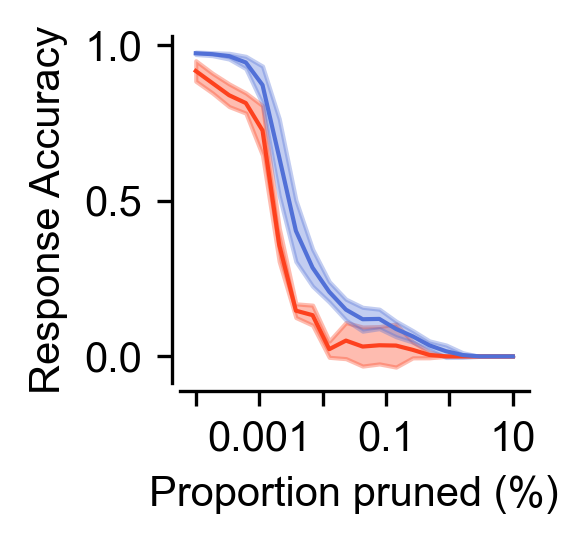

In [28]:
plt.figure(figsize=(1.5,1.5), dpi=300)
gd_c = "#5170d7"
eg_c = "#fd411e"
x_pct = 100 * np.array(prune_props_fine)  # axis units = %

# plt.axhline(eg_base.mean(), color=eg_c, ls="--", lw=0.75, alpha=0.7)
# plt.axhline(gd_base.mean(), color=gd_c, ls="--", lw=0.75, alpha=0.7)

plt.fill_between(x_pct,
                 eg_arr.mean(axis=1) - eg_arr.std(axis=1),
                 eg_arr.mean(axis=1) + eg_arr.std(axis=1),
                 color=eg_c, alpha=0.35)
plt.plot(x_pct, eg_arr.mean(axis=1), color=eg_c, lw=1)

plt.fill_between(x_pct,
                 gd_arr.mean(axis=1) - gd_arr.std(axis=1),
                 gd_arr.mean(axis=1) + gd_arr.std(axis=1),
                 color=gd_c, alpha=0.35)
plt.plot(x_pct, gd_arr.mean(axis=1), color=gd_c, lw=1)

plt.xscale("log")
decades = 10.0 ** np.arange(-4, 2)
plt.xticks(decades, [f"{d:g}" if i % 2 else "" for i, d in enumerate(decades)])
plt.xlabel("Proportion pruned (%)")
plt.ylabel("Response Accuracy")
sns.despine(offset=2, trim=False)
plt.savefig("../figs/reverse_pruning/decc_acc_inverse_s7fix.pdf", transparent=True, bbox_inches="tight")